__Toehold Mediated Strand Exchange (TMSE) Simulations__

Alfred

In [1]:
# Libraries for mathematical analysis
import numpy as np
from skimage import measure
import sympy as sym
import pylab as pl
import matplotlib.pyplot as plt
import scipy.integrate
import biocircuits

# Libraries to visualize results
import bokeh.io
from bokeh.io import show
from bokeh.plotting import figure
from bokeh.plotting import column
import bokeh.palettes
from bokeh.models import LinearColorMapper, ColorBar
from bokeh.models import Range1d
from bokeh.io import export_svgs
from mpl_toolkits.mplot3d import Axes3D
import plotly.graph_objects as go
from bokeh.layouts import row

bokeh.io.output_notebook()

Loading BokehJS ...

<u>TMSE Model</u>

![TMSE Reaction Scheme](TMSE_Reaction.png)

Model of a TMSE system, where an input RNA binds to the toehold region of a Gate-Output RNA complex, releasing the output RNA. The input RNA can also bind a sequestering RNA that inhibits the intput RNA from binding the gate complex.

The system is governed by the following equations:
\begin{align*}
&\dot{m} = \alpha_1 x_1 - \phi m - apm + dc - bzm + uq\\
&\dot{z} = \alpha_2 x_2 - \phi z - bzm + uq\\
&\dot{p} = \theta - \phi p - apm + dc\\
&\dot{c} = apm - dc - \phi c - vc\\
&\dot{y} = vc - \delta y\\
&\dot{q} = bzm - uq - \phi q
\end{align*}

Where:
-   $X_1 = \text{DNA Sequence for Input RNA}$
-   $X_2 = \text{DNA Sequence for Sequestering RNA}$
-   $M = \text{Input RNA}$
-   $P = \text{Gate-RNA Complex}$
-   $C = \text{Input RNA-Gate-Output RNA Complex}$
-   $Y = \text{Free Output RNA}$
-   $Z = \text{Sequestering RNA}$
-   $Q = \text{Sequestered Input RNA}$

<u>Mathematically Derived Decision Boundaries & Activation Functions</u>

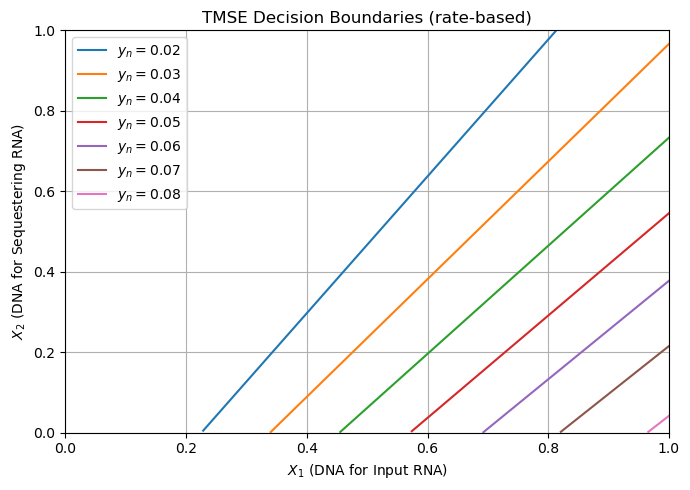

In [2]:
### Define Parameters
# Reaction rates
a   = 10.0   # TMSE input-Gate binding
d   = 1.0    # unbinding
v   = 1.0    # output release
b   = 100.0  # sequestration binding
u   = 0.2    # sequestration unbinding
phi = 0.1    # RNA decay
delta = 0.1  # Output RNA decay

# DNA / Transcription scaling
p_tot  = 1.0
alpha1 = 1.0
alpha2 = 1.0

# Derived parameters
K1  = (phi + d + v) / a
K2  = (u + phi) / b
tau = delta / v          # normalized output scaling
xi  = K2 / K1
xi1 = phi * K1 / ((phi + v) * p_tot)

### Define TMSE decision boundary function
def tmseDecisionBoundary(beta1, y, tau, xi, xi1):
    # If y > 1 --> Convert to normalized y_n
    y_n = y / p_tot if np.any(y > 1) else y
    
    beta2 = (beta1 - xi1 * y_n / (tau - y_n) - y_n / tau) / (y_n / (xi + (1 - xi) * y_n))
    
    # Keep only physically possible values
    beta2[beta2 < 0] = np.nan
    beta2[y_n >= tau] = np.nan
    return beta2


### Plotting
#Define different y-values
yn_values = [0.2*tau, 0.3 * tau, 0.4 * tau, 0.5 * tau, 0.6*tau, 0.7*tau, 0.8 * tau] #Normalized
y_values = [y * p_tot for y in yn_values]  #Not normalized
beta1 = np.linspace(0.01, 3, 1000)

plt.figure(figsize=(7,5))

for y in yn_values:
    beta2 = tmseDecisionBoundary(beta1, y, tau, xi, xi1)
    
    # Convert beta1, beta2 to DNA concentrations
    x1 = beta1 * (phi + v) * p_tot / alpha1
    x2 = beta2 * (phi + v) * p_tot / alpha2
    
    plt.plot(x1, x2, label=rf"$y_n={y:.2f}$")

plt.xlim(0, 1)
plt.ylim(0, 1)
plt.xlabel(r"$X_1$ (DNA for Input RNA)")
plt.ylabel(r"$X_2$ (DNA for Sequestering RNA)")
plt.title("TMSE Decision Boundaries (rate-based)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

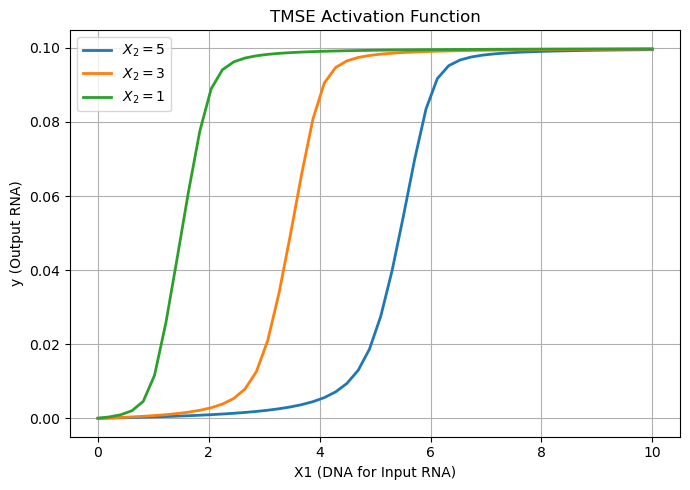

In [18]:
### Define Parameters
# Reaction rates
a   = 10.0    # TMSE input–Gate binding
d   = 1.0     # unbinding
v   = 1.0     # output release
b   = 100.0   # sequestration binding
u   = 0.2     # sequestration unbinding
phi = 0.1     # RNA decay
delta = 0.1   # output RNA decay

# DNA / transcription scaling parameters
p_tot  = 1.0
alpha1 = 1.0
alpha2 = 1.0

# Derived parameters
K1  = (phi + d + v) / a
K2  = (u + phi) / b
tau = delta / v
xi  = K2 / K1
xi1 = phi * K1 / ((phi + v) * p_tot)

###tmseActivationFunction() --> Defines the activation function and solves the polynomial for y
def tmseActivationFunction(x1, x2, xi, xi1, tau, alpha1, alpha2, v, p_tot):
    
    #Dimensionless inputs --> Need to define based on variable x1, x2
    beta1 = (alpha1 * x1) / (v * p_tot)
    beta2 = (alpha2 * x2) / (v * p_tot)
    
    #Define the cubic function for y
    A = (1 - xi)
    B = tau * (beta1 * xi - beta1 + beta2 + xi*xi1 + 2*xi - xi1 - 1)
    C = tau**2 * (beta1 - 2*beta1*xi - beta2 - xi - xi*xi1)
    D = beta1 * xi * tau**3
    
    #Use numpy to solve roots
    roots = np.roots([A, B, C, D])
    realRoots = np.real(roots[np.isreal(roots)])  # Keep real roots
    
    # Physical domain: 0 <= y_n <= tau
    valid = realRoots[(realRoots >= 0) & (realRoots <= tau)]
    
    if len(valid) == 0:
        y_n = 0.0
    else:
        # Biologically relevant --> Largest admissible root
        y_n = np.max(valid)
    
    y = y_n * p_tot
    return y, y_n

### Plotting
#Define values for x1, x2
x2_vals = [5, 3, 1]
x1_vals = np.linspace(0, 10, 50)

plt.figure(figsize=(7,5))
for x2 in x2_vals:
    y_vals = []
    for x1 in x1_vals:
        y, y_n = tmseActivationFunction(x1, x2, xi, xi1, tau, alpha1, alpha2, v, p_tot)
        y_vals.append(y)
        
    y_vals = np.array(y_vals)
    plt.plot(x1_vals, y_vals, linewidth=2, label=rf"$X_2 = {x2}$")

plt.xlabel("X1 (DNA for Input RNA)")
plt.ylabel("y (Output RNA)")
plt.title("TMSE Activation Function")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


<u>Simulated Decision Boundaries & Activation Functions</u>

In [4]:
# Function to do the 2D projection of decision boundaries with normalization  <-- From the EBCP LATAM 2025 Workshop
def contourf(p, x, y, z, title=None, palette="Spectral11", normal = True):
    """Make a filled contour plot given x, y, z data given in 2D arrays."""

    # Normalize the z values
    if normal:
      z_min = z.min()
      z_max = z.max()
      z_normalized = (z - z_min) / (z_max - z_min)  # Normalize to range [0, 1]
    else:
      z_normalized = z

    # Add zero padding at the boundaries for better visualization
    N = z_normalized.shape[1]
    z0 = np.c_[z_normalized, np.zeros(N)]
    z0[-1, -1] = 1.  # Ensure the padding contains a value within range

    # Plot the normalized values
    p.image(
        image=[z0],
        x=x.min(),
        y=y.min(),
        dw=(x.max() - x.min()) * (1 + 1 / N),
        dh=x.max() - x.min(),
        palette=palette,
        alpha=0.8,
    )

    # Color mapping based on the normalized z0 values
    color = LinearColorMapper(palette=palette, low=z0.min(), high=z0.max())
    cb = ColorBar(color_mapper=color, location=(0, 0), width=10)
    p.add_layout(cb, 'right')

    return ()

In [5]:
#Function to help calculate the ODEs
#X --> Sets all conceptrations to 0 at the start
def tmseODEs(X, t, alpha1, alpha2, rates):

    m, z, p, c, y, q = X

    #Unpack rates from array
    phi = rates["phi"] #Decay of RNA
    theta = rates["theta"] #Production of Gate
    a = rates["a"] #Binding of input RNA & Gate
    d = rates["d"] #Dissociation of input RNA & Gate
    v = rates["v"] #Release of output RNA
    delta = rates["delta"] #Decay of output RNA
    b = rates["b"] #Binding of input RNA & sequesterer
    u = rates["u"] #Dissociation of input RNA & sequesterer

    #Write out the ODEs
    dm = alpha1 - phi*m - a*p*m + d*c - b*z*m + u*q
    dz = alpha2 - phi*z - b*z*m + u*q
    dp = theta - phi*p - a*p*m + d*c
    dc = a*p*m - d*c - phi*c - v*c
    dy = v*c - delta*y
    dq = b*z*m - u*q - phi*q

    return [dm, dz, dp, dc, dy, dq]


In [69]:
# Define a grid of input values (x1, x2)
x1 = np.linspace(0, 1, 50)
x2 = np.linspace(0, 1, 50)
X1, X2 = np.meshgrid(x1, x2)

#Activation function inputs
x1Vals = np.linspace(0, 1, 50)
x2Vals = [0.5, 0.5, 0.5]

# Simulation time
t = np.linspace(0, 200, 400)

#Initial species states
X0 = [0, #m
      0, #z
      0, #p
      0, #c
      0, #y
      0] #q

#Weights for x1*alpha1 and x2*alpha2
w1 = 1
w2 = 1

#Kinetics parameters
ratesDefault = {
    'phi': np.array([0.1, 0.1, 0.1]),
    'theta': np.array([0.3, 0.3, 0.3]),
    'a': np.array([10, 10, 10]),
    'd': np.array([1, 1, 1]),
    'v': np.array([1, 1, 1]),
    'delta': np.array([1, 1, 1]),
    'b': np.array([200, 200, 200]),
    'u': np.array([0.05, 0.05, 0.05])
}

#getVariantRates() --> Extracts variant-specific rates from ratesDefault
def getVariantRates(ratesArray, variantIndex):
    rates = {}
    for key, arr in ratesArray.items():
        rates[key] = arr[variantIndex]
    return rates

numVariants = len(ratesDefault['phi']) #phi is in all models --> Best choice

#Bokeh color palette for heatmaps + activation functions
colors = bokeh.palettes.OrRd3

#Array to store all results
results = []

In [70]:
#Range through each variant --> Solve ODEs + Plot heatmap + Plot activation function --> Append to Results
for variantIndex in range(numVariants):
    #Get rates for this current iteration's variant
    rates = getVariantRates(ratesDefault, variantIndex)

    #ODE SOLUTIONS
    #Array for storing scipy.integrate solutions
    gridSolutions = [[None for _ in range(len(x1))] for _ in range(len(x2))]

    # Initialize a matrix to store the steady-state output y
    Y = np.zeros_like(X1)

    # Iterate over the grid values for all variable inputs X1 and X2 --> Solve the ODEs
    for i in range(len(x1)):
        for j in range(len(x2)):
            solutions = scipy.integrate.odeint(tmseODEs, X0, t, args=(w1 * X1[j, i], w2 * X2[j, i], rates))
            gridSolutions[j][i] = solutions
            Y[j, i] = solutions[-1, 4] #Extract the steady state output y

    #HEATMAPS
    p_heatmap = figure(width=350, height=300, title=f"Variant {variantIndex}")

    #Make the heatmap
    contourf(
        p_heatmap,
        X1,
        X2,
        Y,
        palette=bokeh.palettes.Oranges8[::-1],
        normal=True
    )

    p_heatmap.xaxis.axis_label = "X1"
    p_heatmap.yaxis.axis_label = "X2"

    #ACTIVATION FUNCTIONS
    activationFunctions = {}
    p_activation = figure(width=350, height=300, title=f"Variant {variantIndex}")

    for x2j, color in zip(x2Vals, colors):

        curves = []
        output_y = np.zeros_like(x1Vals)

        for i, x1i in enumerate(x1Vals):

            sol = scipy.integrate.odeint(
                tmseODEs, X0, t,
                args=(w1 * x1i, w2 * x2j, rates)
            )

            curves.append(sol)
            output_y[i] = sol[-1, 4]

        activationFunctions[x2j] = curves

        p_activation.line(
            x1Vals,
            output_y,
            line_width=3,
            color=color,
            legend_label=f"X2 = {x2j}"
        )

    p_activation.xaxis.axis_label = "X1 (Input)"
    p_activation.yaxis.axis_label = "y (Output)"
    p_activation.legend.location = "top_left"

    #Append ODE solutions, heatmaps, and activation functions for all variants into the results array
    results.append({
        "variantIndex": variantIndex,
        "rates": rates,
        "solutions": {
            "grid": gridSolutions,
            "activation": activationFunctions
        },
        "heatmaps": p_heatmap,
        "activationFunctions": p_activation
    })

In [71]:
#Plot results
for res in results:
    print(f"\nVariant {res['variantIndex']}")
    for k, v in res["rates"].items():
        print(f"{k}: {v}")

    show(row(res["heatmaps"], res["activationFunctions"]))


Variant 0
phi: 0.1
theta: 0.3
a: 10
d: 1
v: 1
delta: 1
b: 200
u: 0.05



Variant 1
phi: 0.1
theta: 0.3
a: 10
d: 1
v: 1
delta: 1
b: 200
u: 0.05



Variant 2
phi: 0.1
theta: 0.3
a: 10
d: 1
v: 1
delta: 1
b: 200
u: 0.05


In [64]:
### plotActivationFunctionVariants() --> Plots the activation function for every rate variant on the same Bokeh figure, holding X2 fixed, so the effect of the varied rate(s) is directly comparable
def plotActivationFunctionVariants(ratesDefault, x2_fixed, x1Vals, w1, w2, X0, t):
    numVariants = len(ratesDefault['phi'])  # phi is in all models --> Best choice
    colors = bokeh.palettes.OrRd3  # Reuse the same palette as the rest of the notebook

    p_activation = figure(width=500, height=400, title=f"Activation Function Across Rate Variants")

    for variantIndex in range(numVariants):
        rates = getVariantRates(ratesDefault, variantIndex)

        output_y = np.zeros_like(x1Vals)
        for i, x1i in enumerate(x1Vals):
            sol = scipy.integrate.odeint(
                tmseODEs, X0, t,
                args=(w1 * x1i, w2 * x2_fixed, rates)
            )
            output_y[i] = sol[-1, 4]  # Steady-state output y

        p_activation.line(
            x1Vals,
            output_y,
            line_width=3,
            color=colors[variantIndex],
            legend_label=f"Variant {variantIndex}"
        )

    p_activation.xaxis.axis_label = "X1 (Input)"
    p_activation.yaxis.axis_label = "y (Output)"
    p_activation.legend.location = "top_left"

    show(p_activation)
    return p_activation

### Example call --> Hold X2 fixed at one of the existing x2Vals
plotActivationFunctionVariants(ratesDefault, x2_fixed=x2Vals[0], x1Vals=x1Vals, w1=w1, w2=w2, X0=X0, t=t)

figure(id='p5314', ...)

In [65]:
###plotDecisionBoundaryVariants() --> Extracts the Y = threshold contour (the decision boundary) for each rate variant and overlays them on one (X1, X2) plot
def plotDecisionBoundaryVariants(ratesDefault, threshold, x1, x2, X1, X2, w1, w2, X0, t):
    numVariants = len(ratesDefault['phi'])  # phi is in all models --> Best choice
    colors = bokeh.palettes.OrRd3

    p_boundary = figure(width=500, height=400, title=f"Decision Boundary Across Rate Variants (Y = {threshold})")

    for variantIndex in range(numVariants):
        rates = getVariantRates(ratesDefault, variantIndex)

        # Solve the ODEs over the full (X1, X2) grid to get steady-state output Y
        Y = np.zeros_like(X1)
        for i in range(len(x1)):
            for j in range(len(x2)):
                sol = scipy.integrate.odeint(tmseODEs, X0, t, args=(w1 * X1[j, i], w2 * X2[j, i], rates))
                Y[j, i] = sol[-1, 4]  # Steady-state output y

        # Extract the Y = threshold contour --> This is the decision boundary
        contours = measure.find_contours(Y, level=threshold)

        if len(contours) == 0:
            print(f"Variant {variantIndex}: Y never crosses {threshold} on this grid --> no boundary to plot")
            continue

        for c, contour in enumerate(contours):
            #find_contours returns [row_idx, col_idx] into the Y grid --> map indices back to real x1, x2 values
            x1_contour = np.interp(contour[:, 1], np.arange(len(x1)), x1)
            x2_contour = np.interp(contour[:, 0], np.arange(len(x2)), x2)

            line_kwargs = {"line_width": 3, "color": colors[variantIndex]}
            if c == 0:
                line_kwargs["legend_label"] = f"Variant {variantIndex}"  #Only label once per variant

            p_boundary.line(x1_contour, x2_contour, **line_kwargs)

    p_boundary.xaxis.axis_label = "X1"
    p_boundary.yaxis.axis_label = "X2"
    p_boundary.legend.location = "top_left"

    show(p_boundary)
    return p_boundary

###threshold = Y value --> HELD CONSTANT
plotDecisionBoundaryVariants(ratesDefault, threshold=0.5, x1=x1, x2=x2, X1=X1, X2=X2, w1=w1, w2=w2, X0=X0, t=t)

figure(id='p5388', ...)

In [9]:
#3D-Plot of the activation functions
fig = go.Figure(data=[
    go.Surface(z=Y, x=X1, y=X2, colorscale="Viridis")
])

fig.update_layout(
    scene=dict(
        xaxis_title='Input RNA (X1)',
        yaxis_title='Sequesterer RNA (X2)',
        zaxis_title='Ouput (Y)'
    ),
    width=800,
    height=600
)

fig.show()

<u>Stochastic Simulations</u>

In [10]:
# Set up the stoichiometry matrix
tmseUpdate = np.array([
    #Columns: M, Z, P, C, Y, Q
    [ 1,  0,  0,  0,  0,  0],  # X1 --> X1 + M   (Input transcription)
    [-1,  0,  0,  0,  0,  0],  # M --> 0         (Input decay)
    [ 0,  1,  0,  0,  0,  0],  # X2 --> X2 + Z   (Sequesterer transcription)
    [ 0, -1,  0,  0,  0,  0],  # Z --> 0         (Sequesterer decay)
    [ 0,  0,  1,  0,  0,  0],  # NIL --> P       (Gate transcription)
    [ 0,  0, -1,  0,  0,  0],  # P --> 0         (Gate decay)
    [-1,  0, -1,  1,  0,  0],  # M + P -> C      (Input-Gate binding)
    [ 1,  0,  1, -1,  0,  0],  # C -> M + P      (Input-Gate unbinding)
    [ 0,  0,  0, -1,  1,  0],  # C -> Y          (Output release)
    [ 0,  0,  0, -1,  0,  0],  # C --> 0         (Input-gate decay)
    [ 0,  0,  0,  0, -1,  0],  # Y --> 0         (Output decay)
    [-1, -1,  0,  0,  0,  1],  # M + Z -> Q      (Sequestration)
    [ 1,  1,  0,  0,  0, -1],  # Q -> M + Z      (Unsequestration)
    [ 0,  0,  0,  0,  0, -1],  # Q --> 0         (Sequestered decay)
], dtype=int)


In [11]:
#Set up the propensity matrix for each reaction --> Represents the probabilities that each chemical reaction will occur at a given point in time
def tmsePropensity(propensities, population, t, alpha1, alpha2, theta, phi, delta, a, d, b, u, v, omega):
    M, Z, P, C, Y, Q = population

    #Transcription --> Needs to be scaled by cell volume Omega
    propensities[0]  = alpha1 * omega   # X1 -> X1 + M
    propensities[1]  = phi * M          # M -> 0
    propensities[2]  = alpha2 * omega   # X2 -> X2 + Z
    propensities[3]  = phi * Z          # Z -> 0
    propensities[4]  = theta * omega    # NIL -> P
    propensities[5]  = phi * P          # P -> 0

    #Input RNA binding/unbding to Gate & Output produciton
    propensities[6]  = a * M * P        # M + P -> C
    propensities[7]  = d * C            # C -> M + P
    propensities[8]  = v * C            # C -> Y (release)
    propensities[9]  = phi * C          # C -> 0 (decay)
    propensities[10] = delta * Y        # Y -> 0

    #Input RNA-Sequestration
    propensities[11] = b * M * Z        # M + Z -> Q
    propensities[12] = u * Q            # Q -> M + Z
    propensities[13] = phi * Q          # Q -> 0 (decay)

In [12]:
# Define kinetic parameters
ratesStochastic = {
    "alpha1": 0.5,   # Input transcription
    "alpha2": 0.3,   # Sequesterer transcription
    "theta": 0.4,    # Gate transcription
    "phi": 0.05,     # RNA decay
    "delta": 0.05,   # Output RNA decay
    "a": 0.01,       # M + P binding
    "d": 0.01,       # M-P unbinding
    "b": 1.0,       # M + Z binding
    "u": 0.01,       # Q -> M + Z
    "v": 0.1,        # C -> Y release
}

# Conversion factor to molecule numbers
omega = 600    #From the workshop --> E. coli cell volume

# Time points
timePoints = np.linspace(0, 1000, 500)

# Initial conditions: M, Z, P, C, Y, Q
populationAt0 = np.array([0, 0, 0, 0, 0, 0])  #Assume all start at zero

# Turn kinetics into a tuple
argsTMSE = (ratesStochastic["alpha1"], ratesStochastic["alpha2"], ratesStochastic["theta"], ratesStochastic["phi"], ratesStochastic["delta"], ratesStochastic["a"], ratesStochastic["d"], ratesStochastic["b"], ratesStochastic["u"], ratesStochastic["v"], omega)

In [13]:
samples = biocircuits.gillespie_ssa(
    tmsePropensity,
    tmseUpdate,
    populationAt0,
    timePoints,
    size=20,
    args=argsTMSE,
    n_threads=2,
    progress_bar=True
)

# Save results
np.save("TMSE_stochastic.npy", samples)

 30%|███       | 6/20 [02:28<05:46, 24.74s/it]/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py:301: UserWarning: resource_tracker: There appear to be 1 leaked semaphore objects to clean up at shutdown: {'/mp-frce89n6'}
  warnings.warn(
/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py:301: UserWarning: resource_tracker: There appear to be 1 leaked semaphore objects to clean up at shutdown: {'/mp-8m_6k77s'}
  warnings.warn(


KeyboardInterrupt: 

In [ ]:
fig_size = [320, 250]
plots = []

# Create a figure for each species
labels = ['Input RNA (M)', 'Sequesterer (Z)', 'Gate (P)',
          'Complex (C)', 'Output RNA (Y)', 'Sequestered (Q)']

for _ in range(6):
    plots.append(bokeh.plotting.figure(width=fig_size[0], height=fig_size[1],
                                       x_axis_label='Time',
                                       y_axis_label='Molecules'))


for traj in range(len(samples)):
    for i in range(6):
        color = bokeh.palettes.Category10[6][i]
        plots[i].line(timePoints, samples[traj,:,i],
                      line_width=2, color=color, legend_label=labels[i])

# Legend placement
for p in plots:
    p.legend.location = 'bottom_right'

bokeh.io.show(bokeh.layouts.column(plots))
